In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../src")


from geodesiq import *

In [77]:
# ----- Define Hamiltonian and its gradient -----
def H_fun(x, z):
    return np.array([[z, x],
                     [x, -z]])

def H_partial(x, z):
    return np.array([[1, 0],
                     [0, -1]])

hamiltonian = Hamiltonian(H_fun, H_partial)

# ----- Set system and control parameters -----
alpha = 3
beta = 3
x = 1
z0 = -10
zf = -z0

hamiltonian.set_parameters(x=x)
hamiltonian.set_control(control_name='z', pulse_initial=z0, pulse_final=zf,
                        initial_state=0, alpha=alpha, beta=beta)

# ----- Solve for optimal pulse -----
hamiltonian.solve_problem(pulse_accuracy=int(1e6))

## Plotting pulse

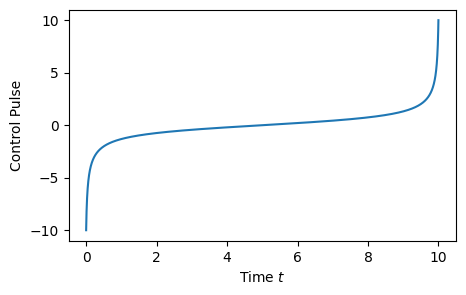

In [78]:
pulse = hamiltonian.synthesize_pulse(duration=10)
fig, ax = pulse.plot_pulse(show=True)


## Discretized pulse


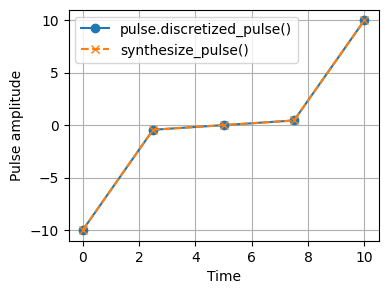

In [72]:
pulse = hamiltonian.synthesize_pulse(duration=10)

steps = 5
discretized_pulse = pulse.discretized_pulse(linear_steps=steps)
discretized_pulse_direct = hamiltonian.synthesize_pulse(duration=10, method='discretized', pulse_kwargs={'linear_steps' : steps})

t1, p1 = discretized_pulse
t2, p2 = discretized_pulse_direct

plt.figure(figsize=(4,3))

# Plot both to verify they match
plt.plot(t1, p1, 'o-', label='pulse.discretized_pulse()')
plt.plot(t2, p2, 'x--', label='synthesize_pulse()')

plt.xlabel("Time")
plt.ylabel("Pulse amplitude")
plt.legend()
plt.grid(True)

plt.show()

## Filtered pulse

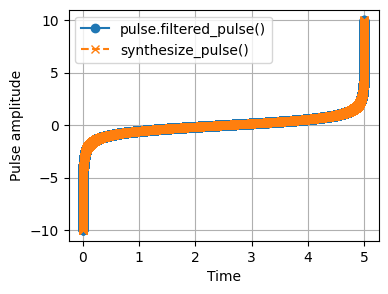

In [74]:
pulse = hamiltonian.synthesize_pulse(duration=5)
filtered_pulse = pulse.filtered_pulse()
filtered_pulse_direct = hamiltonian.synthesize_pulse(duration=5, method='filtered')

t1, p1 = filtered_pulse
t2, p2 = filtered_pulse_direct

plt.figure(figsize=(4,3))

# Plot both to verify they match
plt.plot(t1, p1, 'o-', label='pulse.filtered_pulse()')
plt.plot(t2, p2, 'x--', label='synthesize_pulse()')

plt.xlabel("Time")
plt.ylabel("Pulse amplitude")
plt.legend()
plt.grid(True)

plt.show()

## Fourier spectrum

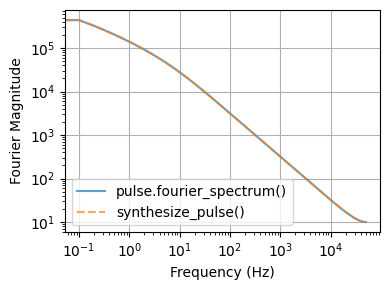

In [81]:
pulse = hamiltonian.synthesize_pulse(duration=10)
fourier = pulse.fourier_spectrum()
fourier_direct = hamiltonian.synthesize_pulse(duration=10, method='fourier')


freq1, mag1 = fourier
freq2, mag2 = fourier_direct

plt.figure(figsize=(4,3))

plt.plot(freq1, mag1, label='pulse.fourier_spectrum()', alpha=0.7)
plt.plot(freq2, mag2, '--', label='synthesize_pulse()', alpha=0.7)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier Magnitude")
plt.legend()
plt.grid(True)

plt.yscale('log')
plt.xscale('log')

plt.tight_layout()
plt.show()
